<h1 style="font-size:25px; font-weight:700; margin-bottom:-10px;">
Regularized Regression Methods
</h1>
<div style="font-size:24px; font-family:'Times New Roman', Times, serif; margin-top:0px;">
<i>Closed-form ridge regression, adaptive LASSO, elastic net, and group LASSO applied to three regression and classification problems</i>
</div>

---

## Abstract

This notebook demonstrates four regularized regression techniques across three self-contained problems. First, the closed-form ridge regression estimator is derived analytically. Second, ridge, LASSO, adaptive LASSO, and elastic net are compared for forecasting maximum and minimum air temperatures in Seoul, evaluated by cross-validated test error and the sparsity of the resulting coefficients. Third, group LASSO is applied to two problems with naturally grouped predictors: a regression task predicting a servomechanism's rise time from gain settings and mechanical-linkage choices, and a logistic classification task predicting colon cancer status from gene-expression features expanded into basis-spline groups.

## Introduction

Regularized regression methods extend ordinary least squares by penalizing the size of the coefficient vector, trading a small increase in bias for a meaningful reduction in variance when predictors are numerous, correlated, or naturally grouped. This notebook works through three settings where that trade-off matters. The first section derives the ridge regression estimator in closed form, establishing the mechanics later sections build on. The second section compares ridge, LASSO, adaptive LASSO, and elastic net penalties on a temperature-forecasting problem, examining how each balances shrinkage against variable selection. The third section applies group LASSO, which shrinks or eliminates predictors in blocks rather than individually, to a regression problem with grouped categorical predictors and a classification problem where each gene is represented by several spline-basis features.

---

## Ridge Regression: Closed-Form Solution

--- 

The Ridge objective function in matrix form is:

$$
\min_{\beta \in \mathbb{R}^{p}} \; \frac{1}{2}\|y - X\beta\|_2^2 + \frac{\lambda}{2}\|\beta\|_2^2
$$

where:

- $ y \in \mathbb{R}^{n} $ are the observed outputs ($n$ is the number of observations)
- $ X \in \mathbb{R}^{n \times p} $ are the observed inputs
- $ \beta \in \mathbb{R}^{p} $ are the parameters to be estimated
- $ \lambda \ge 0 $ is a tuning parameter that controls the amount of shrinkage

Show that the Ridge regression problem has the following closed-form solution:

$$
\hat{\beta} = \left(X^{T}X + \lambda I_p \right)^{-1} X^{T}y
$$

where $I_p$ is the identity matrix of $p \times p$. <br>
**Hint:** Differentiate the objective function with respect to $\beta$, and solve the equation

$$
\frac{\partial}{\partial \beta} \left[ \frac{1}{2}\|y - X\beta\|_2^2 + \frac{\lambda}{2}\|\beta\|_2^2 \right] 
= 0
$$

--- 


<i>Ridge regression closed-form solution:</i>

$ \hat{\beta} = (X^T X + \lambda I_p)^{-1}X^T y $ <br><br>


<i>Ridge regression objective function:</i>

$ \min_{\beta \in \mathbb{R}^p} \frac{1}{2}|y - X\beta|_2^2 + \frac{\lambda}{2}|\beta|_2^2 $ <br><br>


<i>Expand objective function:</i>

$ \frac{1}{2}(y - X\beta)^T(y - X\beta) + \frac{\lambda}{2}\beta^T\beta $ <br><br>


<i>Gradient with respect to $\beta$:</i>

$
\frac{\partial}{\partial \beta} \left[ \frac{1}{2}|y - X\beta|_2^2 +
\frac{\lambda}{2}|\beta|_2^2 \right] -X^T(y - X\beta) + \lambda \beta
$ <br><br>


<i>Set derivative equal to zero:</i>

$ -X^T(y - X\beta) + \lambda \beta = 0 $ <br><br>


<i>Expand, simplify, and factor out $\beta$:</i>

$ -X^Ty + X^TX\beta + \lambda \beta = 0 $

$ X^TX\beta + \lambda \beta = X^Ty $

$ (X^TX + \lambda I_p)\beta = X^Ty $ <br><br>


<i>Solve for $\beta$:</i>

$ 
\color{blue}{(X^T X + \lambda I_p)^{-1}} (X^T X + 
\lambda I_p)\beta = \color{blue}{(X^T X + \lambda I_p)^{-1}} X^T y
$

$ \hat{\beta} = (X^TX + \lambda I_p)^{-1}X^Ty $ <br><br>


<i>Therefore, the closed-form Ridge regression solution is:</i>

$ \boxed{\hat{\beta} = (X^TX + \lambda I_p)^{-1}X^Ty} $ <br><br>


## Ridge, LASSO, Adaptive LASSO & Elastic Net: Forecasting Air Temperatures

<hr style="border:1.5px solid black">


Forecasts of maximum and minimum air temperatures are essential to mitigate the damage of extreme weather events such as heat waves and tropical nights. The study area is a metropolitan city, Seoul ($605 \text{ km}^2$), with over 10 million people.

Seoul is geographically surrounded by four distinct mountains and is divided into the northern and southern parts by the Han River. It is hot and humid due to the East Asian monsoon in summer, so there are a lot of days with hot weather above $30^\circ C$, and precipitation is concentrated in summer, i.e., seasonal rainfall is 892.1 mm in summer and 67.3 mm in winter.

The data is for the purpose of bias correction of next-day maximum and minimum air temperatures forecast of the Local Data Assimilation and Prediction System (LDAPS) model operated by the Korea Meteorological Administration. This data consists of summer data from 2013 to 2017.

The input data is largely composed of the LDAPS model’s next-day forecast data, in-situ maximum and minimum temperatures of present-day, and geographic auxiliary variables.

**`Question2.csv`** contains the data set. Use the **first 5000 samples for training** and the rest for the test. The output is **next-day maximum**, which is the last column of the data set.


In [1]:
# Standard Library
import os

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Model Selection
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV

# Models
from sklearn.linear_model import (
    ElasticNet,
    ElasticNetCV,
    Lasso, 
    lasso_path,
    LassoCV,
    Ridge,
    RidgeCV,
)

# Metrics
from sklearn.metrics import mean_squared_error, r2_score

# Global Variables
rand_seed = 7


---

### Standardization

All features are standardized to zero mean and a standard deviation of 1.

---


The predictor variables were standardized using **StandardScaler**, with the scaler fit only on the 5,000 training observations. The same scaling was then applied to the test data so both datasets were on the same scale. The response variable was left unchanged.


In [2]:
# Load Data
df = pd.read_csv('data/Question2-1.csv', encoding = 'latin1')

print(df.shape)
display(df.head())


(6082, 22)


,Present_Tmax,Present_Tmin,LDAPS_RHmin,LDAPS_RHmax,LDAPS_Tmax_lapse,LDAPS_Tmin_lapse,LDAPS_WS,LDAPS_LH,LDAPS_CC1,LDAPS_CC2,...,LDAPS_PPT1,LDAPS_PPT2,LDAPS_PPT3,LDAPS_PPT4,lat,lon,DEM,Slope,Solar.radiation,Next_Tmax
0,28.7,21.4,58.25569,91.11636,28.07410,23.00694,6.818887,69.451805,0.233947,0.203896,...,0.0,0.0,0.0,0.0,37.6046,126.991,212.3350,2.7850,5992.896,29.1
1,31.9,21.6,52.26340,90.60472,29.85069,24.03501,5.691890,51.937448,0.225508,0.251771,...,0.0,0.0,0.0,0.0,37.6046,127.032,44.7624,0.5141,5869.312,30.5
2,31.6,23.3,48.69048,83.97359,30.09129,24.56563,6.138224,20.573050,0.209344,0.257469,...,0.0,0.0,0.0,0.0,37.5776,127.058,33.3068,0.2661,5863.556,31.1
3,32.0,23.4,58.23979,96.48369,29.70463,23.32618,5.650050,65.727144,0.216372,0.226002,...,0.0,0.0,0.0,0.0,37.6450,127.022,45.7160,2.5348,5856.965,31.7
4,31.4,21.9,56.17410,90.15513,29.11393,23.48648,5.735004,107.965535,0.151407,0.249995,...,0.0,0.0,0.0,0.0,37.5507,127.135,35.0380,0.5055,5859.552,31.2


In [3]:
# Train/Test Split
train_df = df.iloc[:5000].copy()
test_df  = df.iloc[5000:].copy()

target_col = df.columns[-1]

X_train = train_df.drop(columns = [target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns = [target_col])
y_test = test_df[target_col]

print(f'Training Samples: {X_train.shape[0]}')
print(f'Testing Samples : {X_test.shape[0]}')
print(f'Features        : {X_train.shape[1]}')


Training Samples: 5000
Testing Samples : 1082
Features        : 21


In [4]:
# Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)


(5000, 21)
(1082, 21)


In [5]:
# Verify Feature Standardization
print('Training Feature Means:')
print(np.round(X_train_scaled.mean(axis = 0), 6))

print('\nTraining Feature Standard Deviations:')
print(np.round(X_train_scaled.std(axis = 0), 6))


Training Feature Means:
[-0. -0. -0. -0.  0.  0.  0. -0.  0.  0. -0.  0.  0.  0.  0. -0. -0.  0.
  0. -0. -0.]

Training Feature Standard Deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


---

### Model Fitting: Ridge, LASSO, Adaptive LASSO & Elastic Net

**Ridge Regression**, **LASSO Regression**, **Adaptive LASSO Regression** using Ridge weights, and **Elastic Net Regression** are each fit with cross-validation used to tune hyperparameters.

---


### *Ridge Regression*

A Ridge regression model was trained using the standardized predictor variables. Five-fold cross-validation was used to select the optimal regularization parameter, resulting in λ = 351.119173. The final model achieved a test Mean Squared Error (MSE) of 2.059015. The largest estimated coefficient magnitude after Ridge regularization was associated with LDAPS_Tmax_lapse, indicating that it had the strongest influence on the fitted Ridge model. Since Ridge regression shrinks coefficients but does not set them exactly to zero, all 21 predictors remained in the model, with LDAPS_PPT3 having the smallest coefficient magnitude.


In [6]:
# Ridge Regression w/5-Fold Cross-Validation
lambda_grid = np.logspace(-4, 4, 100)

ridge_grid = GridSearchCV(
    estimator = Ridge(),
    param_grid = {'alpha': lambda_grid},
    cv = 5,
    scoring = 'neg_mean_squared_error',
    return_train_score = False
)

ridge_grid.fit(X_train_scaled, y_train)

best_ridge_model = ridge_grid.best_estimator_

ridge_lambda_min = ridge_grid.best_params_['alpha']
ridge_cv_mse = -ridge_grid.best_score_
ridge_cv_std = ridge_grid.cv_results_['std_test_score'][ridge_grid.best_index_]

print(f'Ridge λ min: {ridge_lambda_min:.6f}')
print(f'Minimum CV MSE: {ridge_cv_mse:.6f}')
print(f'CV Std Dev: {ridge_cv_std:.6f}')


Ridge λ min: 351.119173
Minimum CV MSE: 2.434355
CV Std Dev: 0.447914


In [7]:
# Ridge Regression Evaluation
ridge_pred = ridge_grid.predict(X_test_scaled)
ridge_test_mse = mean_squared_error(y_test, ridge_pred)

print(f'Ridge Test MSE: {ridge_test_mse:.6f}')


Ridge Test MSE: 2.059015


In [8]:
# Ridge Coefficients
ridge_coef_df = (
    pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': best_ridge_model.coef_
    })
    .assign(Abs_Coefficient = lambda df: df['Coefficient'].abs())
    .sort_values('Abs_Coefficient', ascending = False)
)

display(ridge_coef_df.reset_index(drop = True))


,Feature,Coefficient,Abs_Coefficient
0,LDAPS_Tmax_lapse,1.364654,1.364654
1,LDAPS_Tmin_lapse,0.397468,0.397468
2,Present_Tmax,0.378155,0.378155
3,LDAPS_CC1,-0.369458,0.369458
4,LDAPS_WS,-0.357161,0.357161
5,LDAPS_CC4,-0.271386,0.271386
6,LDAPS_LH,0.251867,0.251867
7,Slope,0.235016,0.235016
8,LDAPS_CC2,-0.201394,0.201394
9,LDAPS_CC3,-0.196942,0.196942


In [9]:
# Most & Least Informative Features
most_feature = ridge_coef_df.iloc[0]
least_feature = ridge_coef_df.iloc[-1]

print('Most Informative Feature:')
print(most_feature)

print('\nSmallest Coefficient:')
print(least_feature)


Most Informative Feature:
Feature            LDAPS_Tmax_lapse
Coefficient                1.364654
Abs_Coefficient            1.364654
Name: 4, dtype: object

Smallest Coefficient:
Feature            LDAPS_PPT3
Coefficient         -0.012654
Abs_Coefficient      0.012654
Name: 14, dtype: object


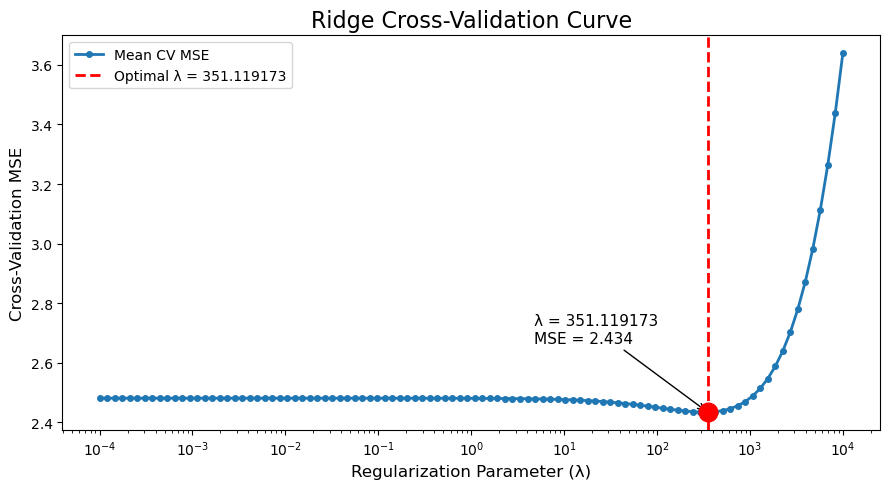

In [10]:
# Plot: Ridge Cross-Validation Curve
cv_results_df = pd.DataFrame({
    'lambda': ridge_grid.cv_results_['param_alpha'].astype(float),
    'cv_mse': -ridge_grid.cv_results_['mean_test_score'],
    'cv_std': ridge_grid.cv_results_['std_test_score']
})

best_row = cv_results_df.loc[cv_results_df['cv_mse'].idxmin()]

plt.figure(figsize = (9,5))

plt.plot(
    cv_results_df['lambda'],
    cv_results_df['cv_mse'],
    marker = 'o',
    linewidth = 2,
    markersize = 4,
    label = 'Mean CV MSE'
)

plt.scatter(
    best_row['lambda'],
    best_row['cv_mse'],
    color = 'red',
    s = 180,
    zorder = 5
)

plt.axvline(
    best_row['lambda'],
    color = 'red',
    linestyle = '--',
    linewidth = 2,
    label = f'Optimal λ = {best_row["lambda"]:.6f}'
)

plt.annotate(
    f'λ = {best_row["lambda"]:.6f}\nMSE = {best_row["cv_mse"]:.3f}',
    xy = (best_row['lambda'], best_row['cv_mse']),
    xytext = (-125, 50),
    textcoords = 'offset points',
    fontsize = 11,
    arrowprops = dict(arrowstyle = '->')
)

plt.xscale('log')
plt.xlabel('Regularization Parameter (λ)', fontsize = 12)
plt.ylabel('Cross-Validation MSE', fontsize = 12)
plt.title('Ridge Cross-Validation Curve', fontsize = 16)
plt.grid(False)
plt.legend()

plt.tight_layout()
plt.show()


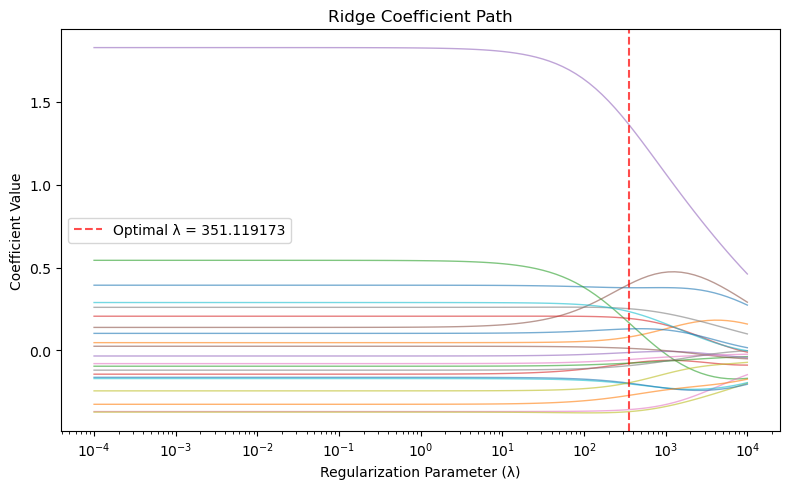

In [11]:
# Plot: Ridge Coefficient Path
ridge_coefs = []
for lam in lambda_grid:
    ridge_model = Ridge(alpha = lam)
    ridge_model.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge_model.coef_)

ridge_coefs = np.array(ridge_coefs)

plt.figure(figsize = (8, 5))

for i, feature in enumerate(X_train.columns):
    plt.semilogx(
        lambda_grid,
        ridge_coefs[:, i],
        linewidth = 1,
        alpha = 0.6
    )

plt.axvline(
    ridge_lambda_min,
    color = 'red',
    linestyle = '--',
    alpha = 0.7,
    label = f'Optimal λ = {ridge_lambda_min:.6f}'
)

plt.xlabel('Regularization Parameter (λ)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Coefficient Path')
plt.grid(False)
plt.legend()

plt.tight_layout()
plt.show()


### *Lasso Regression*

A LASSO regression model was trained using standardized predictor variables, with the optimal regularization parameter selected using 5-fold cross-validation. The selected value was λ = 0.022051, and the final model achieved a test Mean Squared Error (MSE) of 2.112655. Among the retained predictors, LDAPS_Tmax_lapse had the largest absolute coefficient, indicating the strongest contribution to the fitted linear model after regularization. Unlike Ridge regression, which shrinks coefficients toward zero but generally retains all predictors, LASSO performed feature selection by shrinking the coefficient for LDAPS_PPT4 exactly to zero, effectively removing that predictor from the model while retaining the remaining 20 predictors.


In [12]:
# LASSO Regression w/5-Fold Cross-Validation
lambda_grid = np.logspace(-4, 4, 100)

lasso_cv = LassoCV(
    alphas = lambda_grid,
    cv = 5,
    random_state = rand_seed,
    max_iter = 100000
)

lasso_cv.fit(X_train_scaled, y_train)

# Optimal lambda
lasso_lambda_min = lasso_cv.alpha_

print(f'LASSO λ min: {lasso_lambda_min:.6f}')


LASSO λ min: 0.022051


In [13]:
# LASSO Regression Evaluation
lasso_pred = lasso_cv.predict(X_test_scaled)
lasso_test_mse = mean_squared_error(y_test, lasso_pred)

rmse = np.sqrt(lasso_test_mse)
r2 = r2_score(y_test, lasso_pred)

print(f'Test MSE : {lasso_test_mse:.6f}')
print(f'Test RMSE: {rmse:.6f}')
print(f'Test R²  : {r2:.4f}')


Test MSE : 2.112655
Test RMSE: 1.453497
Test R²  : 0.8434


In [14]:
# LASSO Coefficients
lasso_coef_df = (
    pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': lasso_cv.coef_
    })
    .assign(Abs_Coefficient = lambda df: df['Coefficient'].abs())
    .sort_values('Abs_Coefficient', ascending = False)
)

display(lasso_coef_df.reset_index(drop = True))


,Feature,Coefficient,Abs_Coefficient
0,LDAPS_Tmax_lapse,1.730876,1.730876
1,Present_Tmax,0.402669,0.402669
2,LDAPS_CC1,-0.377199,0.377199
3,LDAPS_RHmin,0.331829,0.331829
4,LDAPS_WS,-0.328567,0.328567
5,LDAPS_CC4,-0.290959,0.290959
6,LDAPS_LH,0.231414,0.231414
7,LDAPS_Tmin_lapse,0.188813,0.188813
8,Slope,0.187381,0.187381
9,LDAPS_PPT2,0.159781,0.159781


In [15]:
# Selected & Removed Features
selected_features_lasso = lasso_coef_df[lasso_coef_df['Coefficient'] != 0]
removed_features_lasso = lasso_coef_df[lasso_coef_df['Coefficient'] == 0]

print(f'Number of Selected Features: {selected_features_lasso.shape[0]}')
print(f'Number of Removed Features : {removed_features_lasso.shape[0]}')

print('\nRemoved Features:')
display(removed_features_lasso)


Number of Selected Features: 20
Number of Removed Features : 1

Removed Features:


,Feature,Coefficient,Abs_Coefficient
15,LDAPS_PPT4,0.0,0.0


In [16]:
# Sparsity
nonzero = np.sum(lasso_cv.coef_ != 0)
zero = np.sum(lasso_cv.coef_ == 0)

print(f'Selected Features: {nonzero}')
print(f'Removed Features : {zero}')
print(f'Sparsity         : {100 * zero / len(lasso_cv.coef_):.1f}%')


Selected Features: 20
Removed Features : 1
Sparsity         : 4.8%


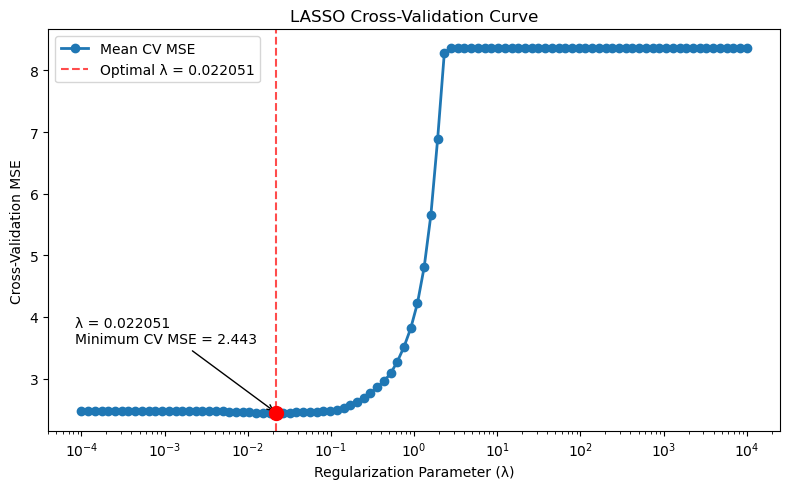

In [17]:
# Plot: LASSO Cross-Validation Curve
mean_cv_mse = lasso_cv.mse_path_.mean(axis = 1)
std_cv_mse = lasso_cv.mse_path_.std(axis = 1)

best_idx = np.argmin(mean_cv_mse)
best_lambda = lasso_cv.alphas_[best_idx]
best_mse = mean_cv_mse[best_idx]

plt.figure(figsize = (8, 5))

plt.semilogx(
    lasso_cv.alphas_,
    mean_cv_mse,
    marker = 'o',
    linewidth = 2,
    label = 'Mean CV MSE'
)

plt.scatter(
    best_lambda,
    best_mse,
    color = 'red',
    s = 100,
    zorder = 5
)

plt.axvline(
    best_lambda,
    color = 'red',
    linestyle = '--',
    alpha = 0.7,
    label = f'Optimal λ = {best_lambda:.6f}'
)

plt.annotate(
    f'λ = {best_lambda:.6f}\nMinimum CV MSE = {best_mse:.3f}',
    xy = (best_lambda, best_mse),
    xytext = (-145, 50),
    textcoords = 'offset points',
    arrowprops = dict(arrowstyle = '->')
)

plt.xlabel('Regularization Parameter (λ)')
plt.ylabel('Cross-Validation MSE')
plt.title('LASSO Cross-Validation Curve')
plt.grid(False)
plt.legend()

plt.tight_layout()
plt.show()


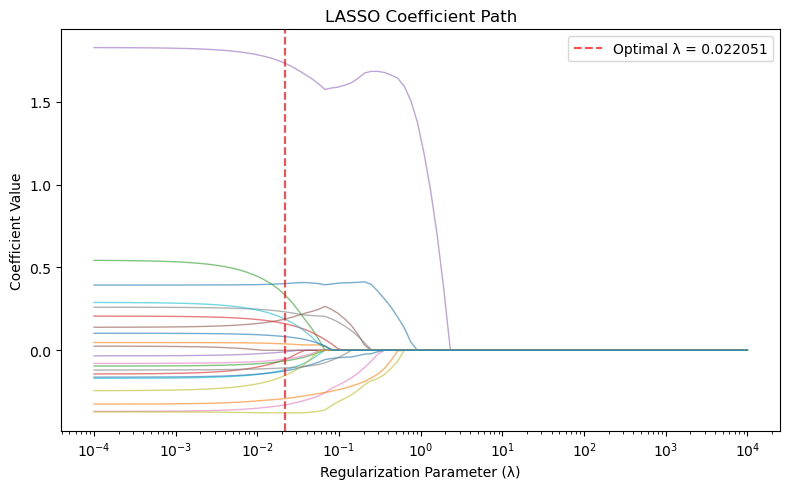

In [18]:
# Plot: LASSO Coefficient Path
alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled,
    y_train,
    alphas = lambda_grid,
    max_iter = 100000
)

plt.figure(figsize = (8, 5))

for i, feature in enumerate(X_train.columns):
    plt.semilogx(
        alphas_path,
        coefs_path[i, :],
        linewidth = 1,
        alpha = 0.6
    )

plt.axvline(
    lasso_lambda_min,
    color = 'red',
    linestyle = '--',
    alpha = 0.7,
    label = f'Optimal λ = {lasso_lambda_min:.6f}'
)

plt.xlabel('Regularization Parameter (λ)')
plt.ylabel('Coefficient Value')
plt.title('LASSO Coefficient Path')
plt.grid(False)
plt.legend()

plt.tight_layout()
plt.show()


### *Adaptive Lasso Regression*

In this implementation, Adaptive LASSO first uses the Ridge regression coefficients as initial estimates. These coefficients are then used to calculate adaptive weights so that predictors with larger Ridge coefficients receive less regularization, while predictors with smaller coefficients receive more shrinkage. After fitting the weighted LASSO model, the optimal regularization parameter was λ = 0.008697, producing a test MSE of 2.1292. The model retained 15 of the 21 predictors and removed six variables (LDAPS_PPT1, LDAPS_PPT3, LDAPS_PPT4, lat, Present_Tmin, and LDAPS_RHmax). Compared with standard LASSO, Adaptive LASSO produced a sparser model while maintaining similar predictive performance.


In [19]:
# Adaptive Weights
gamma = 1.0
ridge_coef = best_ridge_model.coef_
epsilon = 1e-6

weights = 1 / ((np.abs(ridge_coef) + epsilon) ** gamma)

weight_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Ridge_Coefficient': ridge_coef,
    'Adaptive_Weight': weights
})

display(weight_df)


,Feature,Ridge_Coefficient,Adaptive_Weight
0,Present_Tmax,0.378155,2.644414
1,Present_Tmin,0.080362,12.443581
2,LDAPS_RHmin,0.168935,5.919415
3,LDAPS_RHmax,-0.078059,12.810727
4,LDAPS_Tmax_lapse,1.364654,0.732786
5,LDAPS_Tmin_lapse,0.397468,2.515917
6,LDAPS_WS,-0.357161,2.799846
7,LDAPS_LH,0.251867,3.970340
8,LDAPS_CC1,-0.369458,2.706659
9,LDAPS_CC2,-0.201394,4.965357


In [20]:
# Weighted Predictors
X_train_weighted = X_train_scaled / weights
X_test_weighted = X_test_scaled / weights

# Adaptive LASSO
adaptive_lasso_cv = LassoCV(
    alphas = lambda_grid,
    cv = 5,
    random_state = rand_seed,
    max_iter = 100000
)

adaptive_lasso_cv.fit(X_train_weighted, y_train)

adaptive_lambda_min = adaptive_lasso_cv.alpha_

print(f'Adaptive LASSO λ min: {adaptive_lambda_min:.6f}')


Adaptive LASSO λ min: 0.008697


In [21]:
# Adaptive LASSO Evaluation
adaptive_pred = adaptive_lasso_cv.predict(X_test_weighted)

adaptive_test_mse = mean_squared_error(
    y_test, adaptive_pred
)

print(f'Adaptive LASSO Test MSE: {adaptive_test_mse:.6f}')


Adaptive LASSO Test MSE: 2.129229


In [22]:
# Adaptive LASSO Coefficients
adaptive_coef = adaptive_lasso_cv.coef_ / weights

adaptive_coef_df = (
    pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': adaptive_coef
    })
    .assign(Abs_Coefficient = lambda df: df['Coefficient'].abs())
    .sort_values('Abs_Coefficient', ascending = False)
)

display(adaptive_coef_df.reset_index(drop = True))


,Feature,Coefficient,Abs_Coefficient
0,LDAPS_Tmax_lapse,1.723847,1.723847
1,LDAPS_CC1,-0.425742,0.425742
2,Present_Tmax,0.407005,0.407005
3,LDAPS_CC4,-0.305155,0.305155
4,LDAPS_WS,-0.300583,0.300583
5,LDAPS_Tmin_lapse,0.233621,0.233621
6,LDAPS_LH,0.225847,0.225847
7,LDAPS_RHmin,0.175611,0.175611
8,Slope,0.104856,0.104856
9,LDAPS_PPT2,0.102939,0.102939


In [23]:
# Selected & Removed Features
selected_features_adaptive = adaptive_coef_df[adaptive_coef_df["Abs_Coefficient"] > 1e-8]
removed_features_adaptive = adaptive_coef_df[adaptive_coef_df["Abs_Coefficient"] <= 1e-8]

print(f'Number of Selected Features: {selected_features_adaptive.shape[0]}')
print(f'Number of Removed Features : {removed_features_adaptive.shape[0]}')

print('\nRemoved Features:')
display(removed_features_adaptive)


Number of Selected Features: 15
Number of Removed Features : 6

Removed Features:


,Feature,Coefficient,Abs_Coefficient
12,LDAPS_PPT1,-0.0,0.0
14,LDAPS_PPT3,-0.0,0.0
15,LDAPS_PPT4,-0.0,0.0
16,lat,-0.0,0.0
1,Present_Tmin,0.0,0.0
3,LDAPS_RHmax,-0.0,0.0


### *Elastic Net Regression*

Elastic Net combines the Ridge and LASSO penalties by balancing coefficient shrinkage and variable selection. Five-fold cross-validation selected an optimal regularization parameter of λ = 0.067342 and an L1 ratio of 0.20, indicating that the optimal model placed greater emphasis on the Ridge penalty while retaining a smaller LASSO component for feature selection. The fitted model achieved a test MSE of 2.0605. Elastic Net retained 20 of the 21 predictors, removing only LDAPS_PPT4. Overall, the model provided a balance between predictive accuracy and model simplicity.


In [24]:
# Elastic Net Regression w/5-Fold Cross-Validation
lambda_grid = np.logspace(-4, 4, 100)

l1_grid = np.linspace(0.1, 1.0, 10)

elastic_cv = ElasticNetCV(
    alphas = lambda_grid,
    l1_ratio = l1_grid,
    cv = 5,
    random_state = rand_seed,
    max_iter = 100_000
)

elastic_cv.fit(X_train_scaled, y_train)

elastic_lambda_min = elastic_cv.alpha_
elastic_l1_ratio = elastic_cv.l1_ratio_

print(f'Elastic Net λ min : {elastic_lambda_min:.6f}')
print(f'Optimal L1 Ratio  : {elastic_l1_ratio:.2f}')


Elastic Net λ min : 0.067342
Optimal L1 Ratio  : 0.20


In [25]:
# Elastic Net Evaluation
elastic_pred = elastic_cv.predict(X_test_scaled)
elastic_test_mse = mean_squared_error(y_test, elastic_pred)

print(f'Elastic Net Test MSE: {elastic_test_mse:.6f}')


Elastic Net Test MSE: 2.060475


In [26]:
# Elastic Net Coefficients
elastic_coef_df = (
    pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': elastic_cv.coef_
    })
    .assign(Abs_Coefficient = lambda df: df['Coefficient'].abs())
    .sort_values('Abs_Coefficient', ascending = False)
)

display(elastic_coef_df.reset_index(drop = True))


,Feature,Coefficient,Abs_Coefficient
0,LDAPS_Tmax_lapse,1.402880,1.402880
1,Present_Tmax,0.384828,0.384828
2,LDAPS_Tmin_lapse,0.376998,0.376998
3,LDAPS_CC1,-0.369925,0.369925
4,LDAPS_WS,-0.338178,0.338178
5,LDAPS_CC4,-0.261494,0.261494
6,LDAPS_LH,0.238196,0.238196
7,Slope,0.196085,0.196085
8,LDAPS_CC3,-0.172190,0.172190
9,LDAPS_CC2,-0.171279,0.171279


In [27]:
# Selected & Removed Features
selected_features_elastic = elastic_coef_df[elastic_coef_df['Abs_Coefficient'] > 1e-8]
removed_features_elastic = elastic_coef_df[elastic_coef_df['Abs_Coefficient'] <= 1e-8]

print(f'Number of Selected Features: {selected_features_elastic.shape[0]}')
print(f'Number of Removed Features : {removed_features_elastic.shape[0]}')

print('\nRemoved Features:')
display(removed_features_elastic)


Number of Selected Features: 20
Number of Removed Features : 1

Removed Features:


,Feature,Coefficient,Abs_Coefficient
15,LDAPS_PPT4,0.0,0.0


---

The optimal tuning parameters, coefficients, and Mean Squared Prediction Error (MSE) on the test set are reported and compared below.

---


### *Comparison*

Ridge Regression achieved the lowest test MSE (2.0590), indicating the best predictive performance on the test data while retaining all 21 predictors. Elastic Net produced nearly identical performance (2.0605) while removing one predictor, resulting in a slightly simpler model. LASSO also removed one predictor but produced a slightly higher test MSE (2.1127). Adaptive LASSO retained only 15 of the 21 predictors, removing six variables and producing the sparsest model, although this resulted in the highest test MSE (2.1292). Across all four models, Ridge provided the best predictive accuracy.


In [28]:
# Tuning Parameter & Performance Summary
tuning_df = pd.DataFrame({
    'Model': [
        'Ridge',
        'LASSO',
        'Adaptive LASSO',
        'Elastic Net'
    ],
    'Optimal λ': [
        ridge_lambda_min,
        lasso_lambda_min,
        adaptive_lambda_min,
        elastic_lambda_min
    ],
    'Optimal L1 Ratio': [
        np.nan,
        np.nan,
        np.nan,
        elastic_l1_ratio
    ],
    'Test MSE': [
        ridge_test_mse,
        lasso_test_mse,
        adaptive_test_mse,
        elastic_test_mse
    ]
})

tuning_df['Optimal λ'] = tuning_df['Optimal λ'].round(6)
tuning_df['Optimal L1 Ratio'] = tuning_df['Optimal L1 Ratio'].round(2)
tuning_df['Test MSE'] = tuning_df['Test MSE'].round(4)
tuning_df['Optimal L1 Ratio'] = tuning_df['Optimal L1 Ratio'].fillna('—')

display(tuning_df)


,Model,Optimal λ,Optimal L1 Ratio,Test MSE
0,Ridge,351.119173,—,2.0590
1,LASSO,0.022051,—,2.1127
2,Adaptive LASSO,0.008697,—,2.1292
3,Elastic Net,0.067342,0.2,2.0605


In [29]:
# Model Comparison
comparison_df = pd.DataFrame({
    'Model': [
        'Ridge',
        'LASSO',
        'Adaptive LASSO',
        'Elastic Net'
    ],
    'Selected λ': [
        ridge_lambda_min,
        lasso_lambda_min,
        adaptive_lambda_min,
        elastic_lambda_min
    ],
    'L1 Component': [
        0.00,             # Ridge
        1.00,             # LASSO
        1.00,             # Adaptive LASSO
        elastic_l1_ratio  # Elastic Net
    ],
    'Test MSE': [
        ridge_test_mse,
        lasso_test_mse,
        adaptive_test_mse,
        elastic_test_mse
    ],
    'Nonzero Coefficients': [
        X_train.shape[1],
        selected_features_lasso.shape[0],
        selected_features_adaptive.shape[0],
        selected_features_elastic.shape[0]
    ],
    'Zero Coefficients': [
        0,
        removed_features_lasso.shape[0],
        removed_features_adaptive.shape[0],
        removed_features_elastic.shape[0]
    ]
})

comparison_df['Selected λ'] = comparison_df['Selected λ'].round(6)
#comparison_df['L1 Component'] = comparison_df['L1 Component'].round(2)
comparison_df['L1 Component'] = comparison_df['L1 Component'].map('{:.2f}'.format)
comparison_df['Test MSE'] = comparison_df['Test MSE'].round(4)

display(comparison_df)


,Model,Selected λ,L1 Component,Test MSE,Nonzero Coefficients,Zero Coefficients
0,Ridge,351.119173,0.00,2.0590,21,0
1,LASSO,0.022051,1.00,2.1127,20,1
2,Adaptive LASSO,0.008697,1.00,2.1292,15,6
3,Elastic Net,0.067342,0.20,2.0605,20,1


## Group LASSO: Servomechanism Rise Time & Colon Cancer Classification

<hr style="border:1.5px solid black">


In [30]:
# Standard Library
import os

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Model Selection
from sklearn.model_selection import KFold, StratifiedKFold

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    mean_squared_error
)

# Group LASSO
from group_lasso import GroupLasso, LogisticGroupLasso

# Global Variables
rand_seed = 7


---

### Group LASSO Regression: Servomechanism Rise Time

In this part, we want to use **group lasso** to predict the **rise time** of a servomechanism in terms of two gain settings and two (discrete) choices of mechanical linkages.

**`Question3Part1.csv`** contains **167 data samples**.

### Attribute Information

- **motor:** A, B, C, D, E
- **screw:** A, B, C, D, E
- **pgain:** 3, 4, 5, 6
- **vgain:** 1, 2, 3, 4, 5
- **rise time:** 0.13 to 7.10

Use the **first 100 samples** to build a **group lasso regression model**, and use the remaining samples to evaluate the accuracy of your model.

Report the following:

- $\lambda_{\min}$
- Model coefficients
- Most informative feature
- Uninformative features
- Mean Squared Error (MSE) on the test set

---


### *Evaluation:*

A Group LASSO regression model was developed using the first 100 observations as the training set and evaluated on the remaining 67 observations. The categorical variables (motor and screw) were one-hot encoded, resulting in 12 predictor variables. Four feature groups were defined: motor, screw, pgain, and vgain. Five-fold cross-validation was used to select the optimal regularization parameter, yielding λₘᵢₙ = 0.003562.

The final model achieved a test Mean Squared Error (MSE) of 1.166208. Based on the estimated coefficients, pgain was identified as the most informative predictor, having the largest coefficient magnitude and the highest estimated group importance. The remaining feature groups (screw, motor, and vgain) also retained nonzero coefficients, indicating that they contributed to predicting rise time.

**Most Informative Feature:** pgain

**Uninformative Features:** None. All four feature groups retained nonzero importance after Group LASSO regularization.


In [31]:
# Load Data
df = pd.read_csv('data/Question3Part1.csv', encoding = 'latin1')
df.columns = df.columns.str.strip()

display(df.head())


,motor,screw,pgain,vgain,rise time
0,E,E,5,4,0.281251
1,B,D,6,5,0.506252
2,D,D,4,3,0.356251
3,B,A,3,2,5.500033
4,D,B,6,5,0.356251


In [32]:
# Train/Test Split
train_df = df.iloc[:100].copy()
test_df = df.iloc[100:].copy()

# Features & Target
X_train = train_df.drop(columns = ['rise time'])
y_train = train_df['rise time']

X_test = test_df.drop(columns = ['rise time'])
y_test = test_df['rise time']

print(f'Training Samples: {train_df.shape[0]}')
print(f'Testing Samples : {test_df.shape[0]}')


Training Samples: 100
Testing Samples : 67


In [33]:
# Create Encoder
encoder = OneHotEncoder(
    sparse_output = False,
    handle_unknown = 'ignore'
)

# Fit Training Data
X_train_cat = encoder.fit_transform(X_train[['motor', 'screw']])

# Transform Test Data
X_test_cat = encoder.transform(X_test[['motor', 'screw']])

# Numeric Predictors
X_train_num = X_train[['pgain', 'vgain']].to_numpy()
X_test_num = X_test[['pgain', 'vgain']].to_numpy()

# Combine Categorical & Numeric Features
X_train_final = np.hstack((X_train_cat, X_train_num))
X_test_final = np.hstack((X_test_cat, X_test_num))

print(f'Training Matrix: {X_train_final.shape}')
print(f'Testing Matrix : {X_test_final.shape}')


Training Matrix: (100, 12)
Testing Matrix : (67, 12)


In [34]:
# Define Group Assignments
groups = np.array([
    1, 1, 1, 1, 1,  # motor
    2, 2, 2, 2, 2,  # screw
    3,              # pgain
    4               # vgain
])

print(groups)
print(f'Number of Groups: {len(np.unique(groups))}')


[1 1 1 1 1 2 2 2 2 2 3 4]
Number of Groups: 4


In [35]:
# Group LASSO Cross-Validation
lambda_grid = np.logspace(-4, 1, 30)

kf = KFold(n_splits = 5, shuffle = True, random_state = rand_seed)

cv_results = []
for lam in lambda_grid:
    
    fold_mse = []
    for train_idx, val_idx in kf.split(X_train_final):
        X_tr, X_val = X_train_final[train_idx], X_train_final[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = GroupLasso(
            groups = groups,
            group_reg = lam,
            l1_reg = 0,
            scale_reg = 'group_size',
            supress_warning = True,
            n_iter = 1000,
            tol = 1e-3,
            random_state = rand_seed
        )
        
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        
        mse = mean_squared_error(y_val, y_pred)
        fold_mse.append(mse)
    
    cv_results.append({
        'lambda': lam,
        'cv_mse': np.mean(fold_mse)
    })

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df)


,lambda,cv_mse
0,0.000100,1.382619
1,0.000149,1.382423
2,0.000221,1.382134
3,0.000329,1.381713
4,0.000489,1.381105
5,0.000728,1.380326
6,0.001083,1.378895
7,0.001610,1.377198
8,0.002395,1.375094
9,0.003562,1.372873


In [36]:
# Identify lambda_min
best_row = cv_results_df.loc[cv_results_df['cv_mse'].idxmin()]

lambda_min = best_row['lambda']
min_cv_mse = best_row['cv_mse']

print(f'Optimal Group LASSO λ: {lambda_min:.6f}')
print(f'Minimum CV MSE: {min_cv_mse:.6f}')


Optimal Group LASSO λ: 0.003562
Minimum CV MSE: 1.372873


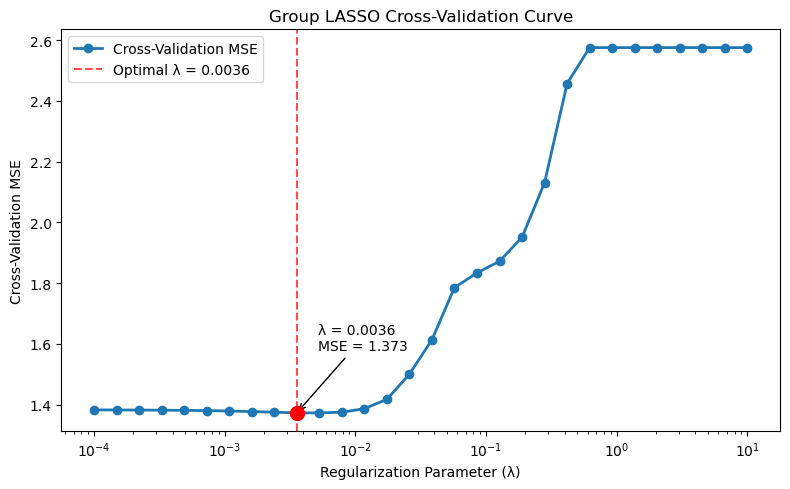

In [37]:
# Plot: Cross-Validation Curve
best_row = cv_results_df.loc[cv_results_df['cv_mse'].idxmin()]
lambda_min = best_row['lambda']
min_cv_mse = best_row['cv_mse']

plt.figure(figsize = (8, 5))

plt.semilogx(
    cv_results_df['lambda'],
    cv_results_df['cv_mse'],
    marker = 'o',
    linewidth = 2,
    label = 'Cross-Validation MSE'
)

plt.scatter(
    lambda_min,
    min_cv_mse,
    color = 'red',
    s = 100,
    zorder = 5
)

plt.axvline(
    lambda_min,
    color = 'red',
    linestyle = '--',
    alpha = 0.7,
    label = f'Optimal λ = {lambda_min:.4f}'
)

plt.annotate(
    f'λ = {lambda_min:.4f}\nMSE = {min_cv_mse:.3f}',
    xy = (lambda_min, min_cv_mse),
    xytext = (15, 45),
    textcoords = 'offset points',
    arrowprops = dict(arrowstyle='->')
)

plt.xlabel('Regularization Parameter (λ)')
plt.ylabel('Cross-Validation MSE')
plt.title('Group LASSO Cross-Validation Curve')
plt.grid(False)
plt.legend()

plt.tight_layout()
plt.show()


In [38]:
# Fit Final Group LASSO Model
final_model = GroupLasso(
    groups = groups,
    group_reg = lambda_min,
    l1_reg = 0,
    scale_reg = 'group_size',
    supress_warning = True,
    n_iter = 1000,
    tol = 1e-3,
    random_state = rand_seed
)
final_model.fit(X_train_final, y_train)

# Predictions & Test MSE
y_pred = final_model.predict(X_test_final)
test_mse = mean_squared_error(y_test, y_pred)

print(f'Test MSE: {test_mse:.6f}')


Test MSE: 1.166208


In [39]:
# Model Coefficients
coef = final_model.coef_.flatten()

feature_names = (
    encoder.get_feature_names_out(['motor', 'screw']).tolist() + ['pgain', 'vgain']
)

coef_df = (
    pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coef
    })
    .sort_values(
        by = 'Coefficient',
        key = lambda x: abs(x),
        ascending = False
    )
)

display(coef_df.reset_index(drop = True))


,Feature,Coefficient
0,pgain,-1.550521
1,screw_A,1.126205
2,motor_D,-0.825665
3,vgain,0.537792
4,screw_D,-0.418562
5,screw_E,-0.396122
6,motor_B,0.372472
7,screw_C,-0.331938
8,motor_A,0.293090
9,motor_C,0.237074


In [40]:
# Group Importance
group_importance = {
    'motor': np.linalg.norm(coef[0:5]),
    'screw': np.linalg.norm(coef[5:10]),
    'pgain': np.linalg.norm(coef[10:11]),
    'vgain': np.linalg.norm(coef[11:12])
}

group_df = (
    pd.DataFrame(
        group_importance.items(),
        columns = ['Group', 'Importance']
    )
    .sort_values('Importance', ascending = False)
)

display(group_df)


,Group,Importance
2,pgain,1.550521
1,screw,1.308069
0,motor,0.984118
3,vgain,0.537792


---

### Logistic Group LASSO Classification: Colon Cancer Prediction

In this part, we want to build a **logistic group lasso classifier** to predict colon cancer.

**`Question3Part2.csv`** contains **62 samples** with **100 predictors**, expanded from **20 genes** using **5 basis B-splines**.

Use the **first 50 samples** to build a **logistic group lasso classifier**, and use the remaining samples to evaluate the accuracy of your classifier.

Report the following:

- $\lambda_{\min}$
- Model coefficients
- Most informative feature
- Uninformative features
- Classification accuracy on the test set

---


### *Evaluation:*

A Logistic Group LASSO classifier was developed to predict colon cancer using the first 50 observations as the training set and the remaining 12 observations as the test set, after removing blank and duplicate rows from the provided dataset (see note below). The 100 predictors were organized into 20 gene-level groups, with each gene represented by five B-spline basis functions.

Five-fold stratified cross-validation was used to select the optimal regularization parameter. The optimal value, λₘᵢₙ = 0.000489, produced the highest mean cross-validation accuracy of 0.8200. The final Logistic Group LASSO model achieved a test classification accuracy of 0.7500. The confusion matrix indicates that the model correctly classified 9 of the 12 test observations (75%), producing 5 true negatives, 4 true positives, 3 false positives, and 0 false negatives.

Group importance was computed as the Euclidean norm of the coefficients within each gene group, providing a single measure of importance for each gene. Based on these group importance values, Gene 14 was identified as the most informative gene group because it exhibited the largest coefficient norm. Gene 3, Gene 4, and Gene 18 were assigned zero group importance, indicating that all coefficients within those gene groups were shrunk to zero by the Logistic Group LASSO regularization penalty.

**Most Informative Gene Group:** Gene 14

**Gene Groups Eliminated by Group LASSO:** Gene 3, Gene 4, and Gene 18

**Test Classification Accuracy:** 0.7500 (9 of 12 correctly classified)



> **Notes:**
> 1. **StratifiedKFold** was used becasue stratified cross-validation preserves the class proportions within each fold, providing a more reliable estimate of classification performance.
> 2. **StandardScaler** was used to standardize predictors because Group LASSO regularization is sensitive to feature scale.


In [41]:
# Load & Clean Data
df = pd.read_csv('data/Question3Part2.csv', encoding = 'latin1')
df = df.dropna(how = 'all').reset_index(drop = True)
df = df.iloc[:62]  # Rows 62-69 Duplicate of Rows 13-20

print(df.shape)
display(df.head())


(62, 101)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101
0,0.062419,0.570427,0.366529,0.000625,0.000000,0.351704,0.048892,0.001587,0.000000,0.000000,...,0.270390,0.656204,0.073388,0.000000,0.000011,0.228284,0.652969,0.118736,0.000000,1.0
1,0.000000,0.013742,0.217157,0.548025,0.221000,0.000000,0.139000,0.659027,0.201955,0.000116,...,0.004808,0.123498,0.480540,0.391154,0.000000,0.038454,0.382604,0.498570,0.080372,1.0
2,0.000000,0.203484,0.635786,0.160705,0.000025,0.123469,0.565298,0.310620,0.000000,0.000000,...,0.379252,0.595410,0.022442,0.000000,0.228442,0.579208,0.187210,0.000000,0.000000,-1.0
3,0.000037,0.251337,0.636661,0.111965,0.000000,0.000000,0.000437,0.031648,0.330000,0.637425,...,0.537427,0.426750,0.000255,0.000000,0.193004,0.590145,0.214430,0.000000,0.000000,1.0
4,0.004817,0.382058,0.575852,0.037273,0.000000,0.023426,0.443704,0.528996,0.003874,0.000000,...,0.448622,0.533781,0.007400,0.000000,0.202531,0.587681,0.206757,0.000000,0.000000,1.0


>**Note:** `Question3Part2.csv` contains 72 rows, not the 62 indicated in the assignment: 2 are blank and 8 (rows 62–69) are duplicates of rows 13–20. After removing blanks and duplicates, 62 unique samples remain (40 positive / 22 negative). The analysis below uses those 62 samples, split 50 training / 12 testing consistent with assignment.


In [42]:
# Train/Test Split
train_df = df.iloc[:50].copy()
test_df = df.iloc[50:].copy()

# Features & Target
target_col = df.columns[-1]

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

# Convert Labels: {-1, 1} to {0, 1}
y_train_bin = (y_train == 1).astype(int)
y_test_bin = (y_test == 1).astype(int)

# Summary
print('Unique Training Labels:', np.unique(y_train_bin))
print(f'Training Shape: {X_train.shape}')
print(f'Testing Shape : {X_test.shape}')


Unique Training Labels: [0 1]
Training Shape: (50, 100)
Testing Shape : (12, 100)


In [43]:
# Standardize Predictors
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create Group Vector
groups = np.repeat(np.arange(1, 21), 5)

print(groups)
print(f'\nNumber of groups: {len(np.unique(groups))}')


[ 1  1  1  1  1  2  2  2  2  2  3  3  3  3  3  4  4  4  4  4  5  5  5  5
  5  6  6  6  6  6  7  7  7  7  7  8  8  8  8  8  9  9  9  9  9 10 10 10
 10 10 11 11 11 11 11 12 12 12 12 12 13 13 13 13 13 14 14 14 14 14 15 15
 15 15 15 16 16 16 16 16 17 17 17 17 17 18 18 18 18 18 19 19 19 19 19 20
 20 20 20 20]

Number of groups: 20


In [44]:
# Hyperparameter Tuning
lambda_grid = np.logspace(-4, 1, 30)

kf = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = rand_seed
)

cv_results = []
for lam in lambda_grid:

    fold_accuracy = []
    for train_idx, val_idx in kf.split(X_train_scaled, y_train_bin):

        X_tr = X_train_scaled[train_idx]
        X_val = X_train_scaled[val_idx]

        y_tr = y_train_bin.iloc[train_idx]
        y_val = y_train_bin.iloc[val_idx]

        model = LogisticGroupLasso(
            groups = groups,
            group_reg = lam,
            l1_reg = 0,
            scale_reg = 'group_size',
            supress_warning = True,
            n_iter = 1000,
            tol = 1e-3,
            random_state = rand_seed
        )

        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)

        fold_accuracy.append(
            accuracy_score(y_val, y_pred)
        )

    cv_results.append({
        'lambda': lam,
        'cv_accuracy': np.mean(fold_accuracy),
        'cv_std': np.std(fold_accuracy)
    })

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df.head())

best_row = cv_results_df.loc[
    cv_results_df['cv_accuracy'].idxmax()
]

lambda_min = best_row['lambda']
best_cv_accuracy = best_row['cv_accuracy']

print(f'\nlambda_min: {lambda_min:.6f}')
print(f'Best CV Accuracy: {best_cv_accuracy:.4f}')
print(f'CV Std Dev: {best_row["cv_std"]:.3f}\n')


,lambda,cv_accuracy,cv_std
0,0.000100,0.78,0.074833
1,0.000149,0.78,0.040000
2,0.000221,0.78,0.040000
3,0.000329,0.78,0.040000
4,0.000489,0.82,0.040000



lambda_min: 0.000489
Best CV Accuracy: 0.8200
CV Std Dev: 0.040



Test Accuracy: 0.7500



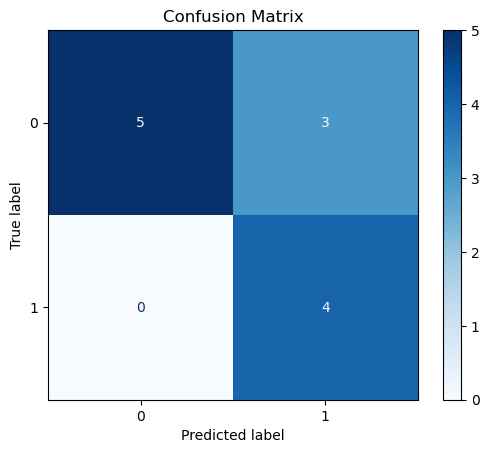

In [45]:
# Final Logistic Group LASSO Model
final_model = LogisticGroupLasso(
    groups = groups,
    group_reg = lambda_min,
    l1_reg = 0,
    scale_reg = 'group_size',
    supress_warning = True,
    n_iter = 1000,
    tol = 1e-3,
    random_state = rand_seed
)

final_model.fit(X_train_scaled, y_train_bin)

# Performance
y_pred = final_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test_bin, y_pred)

print(f'Test Accuracy: {accuracy:.4f}\n')

ConfusionMatrixDisplay.from_predictions(
    y_test_bin, y_pred,
    cmap = 'Blues'
)

plt.title('Confusion Matrix')
plt.show()


In [46]:
# Coefficients for Positive Class
coef = final_model.coef_[:, 1]

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coef
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(
    'Abs_Coefficient',
    ascending = False
)

display(coef_df.reset_index(drop = True).head())


,Feature,Coefficient,Abs_Coefficient
0,V69,-1.236069,1.236069
1,V42,-0.897376,0.897376
2,V67,0.763297,0.763297
3,V81,-0.746949,0.746949
4,V44,-0.711661,0.711661


In [47]:
# Gene Importance
gene_importance = []
for i in range(20):
    
    start = i * 5
    end = start + 5

    importance = np.linalg.norm(coef[start:end])

    gene_importance.append({
        'Gene': f'Gene {i + 1:02d}',
        'Importance': importance
    })

gene_df = (
    pd.DataFrame(gene_importance).sort_values('Importance', ascending = False)
)

display(gene_df.reset_index(drop = True))


,Gene,Importance
0,Gene 14,1.680766
1,Gene 09,1.271799
2,Gene 17,0.895255
3,Gene 19,0.619978
4,Gene 16,0.561739
5,Gene 20,0.487358
6,Gene 11,0.472108
7,Gene 06,0.413010
8,Gene 05,0.360994
9,Gene 12,0.339764


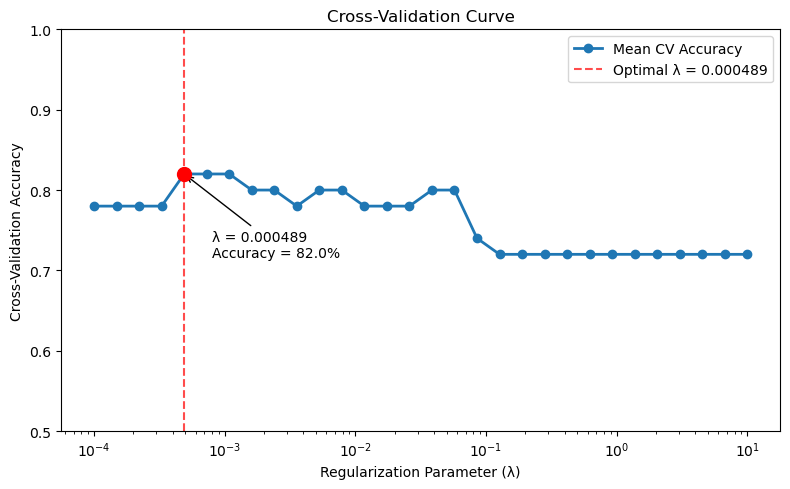

In [48]:
# Plot: Cross-Validation Accuracy
best_row = cv_results_df.loc[
    cv_results_df['cv_accuracy'].idxmax()
]

lambda_min = best_row['lambda']
best_accuracy = best_row['cv_accuracy']
best_std = best_row['cv_std']

plt.figure(figsize = (8, 5))

plt.semilogx(
    cv_results_df['lambda'],
    cv_results_df['cv_accuracy'],
    marker = 'o',
    linewidth = 2,
    label = 'Mean CV Accuracy'
)

# Highlight Optimal Lambda
plt.scatter(
    lambda_min,
    best_accuracy,
    color = 'red',
    s = 100,
    zorder = 5
)

plt.axvline(
    lambda_min,
    color = 'red',
    linestyle = '--',
    alpha = 0.7,
    label = f'Optimal λ = {lambda_min:.6f}'
)

plt.annotate(
    f'λ = {lambda_min:.6f}\nAccuracy = {best_accuracy:.1%}',
    xy = (lambda_min, best_accuracy),
    xytext = (20, -60),
    textcoords = 'offset points',
    arrowprops = dict(arrowstyle = '->')
)

plt.xlabel('Regularization Parameter (λ)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Cross-Validation Curve')

plt.grid(False)
plt.ylim(0.5, 1.0)

plt.legend()
plt.tight_layout()
plt.show()
